In [2]:
import pandas as pd
df = pd.read_csv("customer_churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [12]:
if "customerID" in df.columns:
     df.drop(["customerID"], axis = 1, inplace = True)
df.dtypes

gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges            str
Churn                   str
dtype: object

In [18]:
df["TotalCharges"].values


<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',
 ...
 '2625.25', '6886.25',  '1495.1',   '743.3',  '1419.4',  '1990.5',  '7362.9',
  '346.45',   '306.6',  '6844.5']
Length: 7043, dtype: str

In [23]:
df[pd.to_numeric(df.TotalCharges,errors = "coerce").isnull()]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


In [26]:
df1 = df[df.TotalCharges != " "]
df1.shape

(7032, 20)

In [28]:
df1.TotalCharges = pd.to_numeric(df1.TotalCharges)

In [29]:
df1.TotalCharges.dtype

dtype('float64')

In [33]:
tenure_churn_no =df1[df1.Churn =="No"].tenure
tenure_churn_yes = df1[df1.Churn =="Yes"].tenure

In [34]:
import matplotlib.pyplot as plt

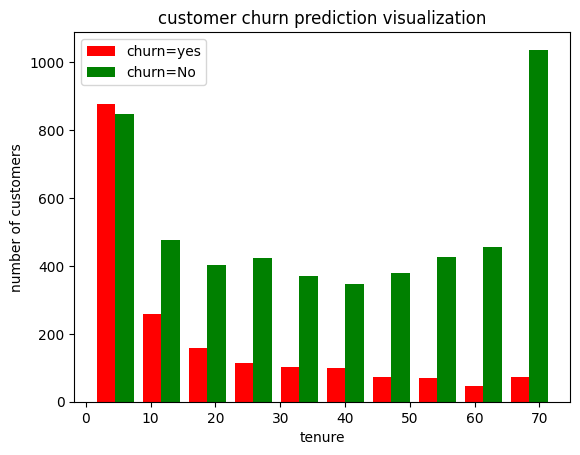

In [43]:
plt.xlabel("tenure")
plt.ylabel("number of customers")
plt.title("customer churn prediction visualization")
plt.hist([tenure_churn_yes, tenure_churn_no], color = ["red", "green"],label = ["churn=yes","churn=No"])
plt.legend()

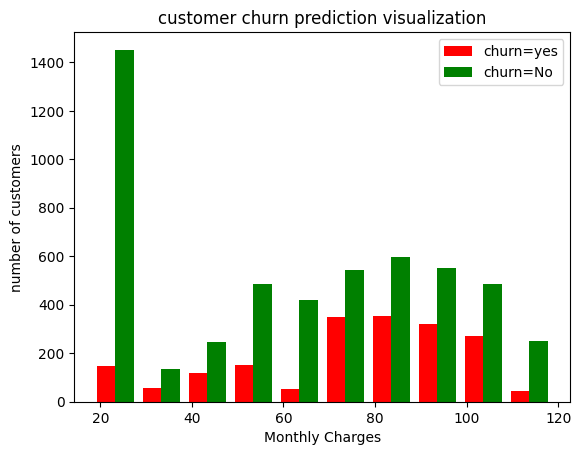

In [44]:
tenure_churn_no =df1[df1.Churn =="No"].MonthlyCharges
tenure_churn_yes = df1[df1.Churn =="Yes"].MonthlyCharges
plt.xlabel("Monthly Charges")
plt.ylabel("number of customers")
plt.title("customer churn prediction visualization")
plt.hist([tenure_churn_yes, tenure_churn_no], color = ["red", "green"],label = ["churn=yes","churn=No"])
plt.legend()

In [55]:
def print_unique_col_values(df):
    for column in df:
        if df[column].dtype == "str":
            print(f'{column} : {df[column].unique()}')

In [56]:
print_unique_col_values(df1)

gender : <StringArray>
['Female', 'Male']
Length: 2, dtype: str
Partner : <StringArray>
['Yes', 'No']
Length: 2, dtype: str
Dependents : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
PhoneService : <StringArray>
['No', 'Yes']
Length: 2, dtype: str
MultipleLines : <StringArray>
['No phone service', 'No', 'Yes']
Length: 3, dtype: str
InternetService : <StringArray>
['DSL', 'Fiber optic', 'No']
Length: 3, dtype: str
OnlineSecurity : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
OnlineBackup : <StringArray>
['Yes', 'No', 'No internet service']
Length: 3, dtype: str
DeviceProtection : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
TechSupport : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingTV : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
StreamingMovies : <StringArray>
['No', 'Yes', 'No internet service']
Length: 3, dtype: str
Contract : <StringArray>
['Month-to-month', 

In [58]:
df1.replace({"No internet service": "No"}, inplace = True)
df1.replace({"No phone service":"No"}, inplace  =True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [62]:
df1.replace({"Female": 1, "Male": 0}, inplace = True)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,0,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,0,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,0,0,No,No,45,No,No,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,1,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,1,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,1,0,Yes,Yes,11,No,No,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,0,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [68]:
yes_no_columns = ["Partner", "Dependents", "PhoneService", "MultipleLines", "OnlineSecurity","OnlineBackup","DeviceProtection",
                             "TechSupport", "StreamingTV", "StreamingMovies","PaperlessBilling", "Churn"]

for col in yes_no_columns:
    df1[col] = df1[col].replace({"Yes": 1, "No": 0})

In [81]:
df2 = pd.get_dummies(df1, columns=["PaymentMethod","InternetService", "Contract"], drop_first = True, dtype = int)
df2

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,OnlineSecurity,OnlineBackup,DeviceProtection,...,MonthlyCharges,TotalCharges,Churn,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,InternetService_Fiber optic,InternetService_No,Contract_One year,Contract_Two year
0,1,0,1,0,1,0,0,0,1,0,...,29.85,29.85,0,0,1,0,0,0,0,0
1,0,0,0,0,34,1,0,1,0,1,...,56.95,1889.50,0,0,0,1,0,0,1,0
2,0,0,0,0,2,1,0,1,1,0,...,53.85,108.15,1,0,0,1,0,0,0,0
3,0,0,0,0,45,0,0,1,0,1,...,42.30,1840.75,0,0,0,0,0,0,1,0
4,1,0,0,0,2,1,0,0,0,0,...,70.70,151.65,1,0,1,0,1,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,0,1,1,24,1,1,1,0,1,...,84.80,1990.50,0,0,0,1,0,0,1,0
7039,1,0,1,1,72,1,1,0,1,1,...,103.20,7362.90,0,1,0,0,1,0,1,0
7040,1,0,1,1,11,0,0,1,0,0,...,29.60,346.45,0,0,1,0,0,0,0,0
7041,0,1,1,0,4,1,1,0,0,0,...,74.40,306.60,1,0,0,1,1,0,0,0


In [82]:
for cols in df2:
    df2[cols] = df2[cols].astype(int)

In [84]:
df2.dtypes

gender                                   int64
SeniorCitizen                            int64
Partner                                  int64
Dependents                               int64
tenure                                   int64
PhoneService                             int64
MultipleLines                            int64
OnlineSecurity                           int64
OnlineBackup                             int64
DeviceProtection                         int64
TechSupport                              int64
StreamingTV                              int64
StreamingMovies                          int64
PaperlessBilling                         int64
MonthlyCharges                           int64
TotalCharges                             int64
Churn                                    int64
PaymentMethod_Credit card (automatic)    int64
PaymentMethod_Electronic check           int64
PaymentMethod_Mailed check               int64
InternetService_Fiber optic              int64
InternetServi

In [93]:
cols_to_scale =["tenure","MonthlyCharges","TotalCharges"]

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df2[cols_to_scale] = scaler.fit_transform(df2[cols_to_scale])

In [96]:
X = df2.drop(["Churn"], axis = 1)
y = df2["Churn"]

In [97]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train,y_test = train_test_split(X,y, test_size = .2, random_state = 12)

In [101]:
len(X_train.columns)

23

In [103]:
import tensorflow as tf
from tensorflow import keras


In [122]:
model =keras.Sequential([
    keras.layers.Input(shape=(23,) ),
    keras.layers.Dense(10, activation = "relu"),
    keras.layers.Dense(1, activation = "sigmoid")
]
)

model.compile(
    optimizer = "adam",
    loss = "binary_crossentropy",
    metrics = ["accuracy"]
)

model.fit(X_train, y_train, epochs = 5)

Epoch 1/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 7s 15ms/step - accuracy: 0.7161 - loss: 0.5625
Epoch 2/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accuracy: 0.7703 - loss: 0.4707
Epoch 3/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.7861 - loss: 0.4427
Epoch 4/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7897 - loss: 0.4327
Epoch 5/5
176/176 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7954 - loss: 0.4268


In [106]:
model.evaluate(X_test, y_test)

44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.8024 - loss: 0.4249


[0.4248713254928589, 0.8024165034294128]

In [108]:
yp = model.predict(X_test)
yp[:5]

44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[0.01253845],
       [0.02480182],
       [0.55105233],
       [0.21698439],
       [0.25199634]], dtype=float32)

In [110]:
y_pred = []

for element in yp:
    if element > .5:
        y_pred.append(1)
    else:
        y_pred.append(0)

In [112]:
y_test[:16]

6226    0
3570    0
6798    0
6489    1
2819    0
4474    0
5887    0
3576    0
5144    0
6903    0
1865    0
331     0
6528    0
168     1
5197    0
6570    0
Name: Churn, dtype: int64

In [111]:
y_pred[:16]

[0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Text(50.722222222222214, 0.5, 'truth')

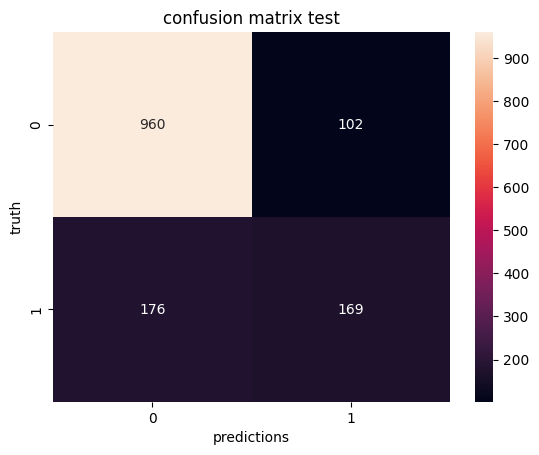

In [118]:
cm = tf.math.confusion_matrix(labels = y_test,predictions = y_pred)
import seaborn as sns
plt.title("confusion matrix test")
sns.heatmap(cm, annot = True, fmt = "d")
plt.xlabel("predictions")
plt.ylabel("truth")

In [119]:
from sklearn.metrics import confusion_matrix, classification_report
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.85      0.90      0.87      1062
           1       0.62      0.49      0.55       345

    accuracy                           0.80      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.79      0.80      0.79      1407

